# 03 — Supervised Learning: Classification
### Predicting `HighValue` Customers — Neural Network vs. Logistic Regression Baseline

---

**Project pipeline (this notebook is stage 3 of 5):**

| Stage | Notebook | Purpose |
|---|---|---|
| 1 | `01_data_preprocessing.ipynb` | Load, clean, engineer `customer_features.csv` |
| 2 | `02_pca_lda.ipynb` | Split customers, label `HighValue`, standardize, PCA/LDA |
| 3 | **`03_classification.ipynb`** ⬅ *you are here* | Train + tune a classifier to predict `HighValue` |
| 4 | `04_regression.ipynb` | Predict next-quarter spend (revenue simulator) |
| 5 | `05_qlearning_dqn.ipynb` | Reinforcement learning, using the classifier/regressor as its environment |

**Task:** binary classification — predict whether a customer is `HighValue` (top 20% by `Monetary`, as labeled in notebook 02) using their 5 standardized category-spend-% features.

**Two candidate models, compared under a strict leakage-free protocol:**
1. **Model 1 — Neural Network (`MLPClassifier`)**: a small feed-forward network, `Input → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)`. Can capture non-linear interactions between category-spend percentages.
2. **Model 2 — Logistic Regression (baseline)**: a linear model. Fast, transparent, and every coefficient has a direct, interpretable meaning ("+1 std-dev of Gadgets spend changes the log-odds of HighValue by X").

**The three-way data split discipline (carried over from notebook 02) is enforced throughout:**
- **Train** → fit both models, and run cross-validated hyperparameter search for Model 1.
- **Validation** → touched *exactly once*, to pick the champion between Model 1 (tuned) and Model 2.
- **Test** → touched *exactly once*, at the very end, to report the final, honest performance number.

> 💡 **Why this discipline matters:** if you peek at the test set more than once — e.g. to "try a different model" after seeing a disappointing test score — the test score stops being an honest estimate of real-world performance. Every metric you'd report afterward would be optimistically biased. This notebook is structured so that's structurally difficult to do by accident.

## 📦 Prerequisites & Data Lineage Check

This notebook expects `02_pca_lda.ipynb` to have already run and saved its outputs. We check for the exact files we need — **and pinpoint precisely which one is missing** if something's wrong — rather than failing with a generic `FileNotFoundError` deep inside a later cell.

> ⚠️ **Path note:** earlier drafts of this notebook pointed at `../data/processed_data/`, but `02_pca_lda.ipynb` actually writes its outputs to **`../data/`** directly (no `processed_data` subfolder). The cell below uses the corrected path. If you've since changed notebook 02 to use a subfolder, update `DATA_DIR` below to match.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [2]:
# ==========================================
# Pinpoint check: do the expected input files exist?
# ==========================================
DATA_DIR = "../data"  # <-- corrected from "../data/processed_data/"

required_files = {
    "train_split.csv": "customer-level training split with HighValue label (from 02_pca_lda.ipynb)",
    "val_split.csv":   "customer-level validation split with HighValue label",
    "test_split.csv":  "customer-level test split with HighValue label",
}

missing = []
for fname, description in required_files.items():
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    marker = "\u2705" if exists else "\u274C"
    print(f"{marker} {fpath:<35} {'FOUND' if exists else 'MISSING'}  -- {description}")
    if not exists:
        missing.append(fpath)

if missing:
    raise FileNotFoundError(
        "Missing required input file(s):\n  " + "\n  ".join(missing) +
        "\n\nRun 02_pca_lda.ipynb first -- its final 'Save Outputs' section produces these files."
    )

print("\nAll required input files found. Proceeding to load.")

✅ ../data\train_split.csv             FOUND  -- customer-level training split with HighValue label (from 02_pca_lda.ipynb)
✅ ../data\val_split.csv               FOUND  -- customer-level validation split with HighValue label
✅ ../data\test_split.csv              FOUND  -- customer-level test split with HighValue label

All required input files found. Proceeding to load.


## 1. Load Pre-Split Labeled Customer Data

### ⚠️ Feature set expanded from the original 5 category-% columns

The original version of this notebook used **only** the 5 category-spend-% columns as features. That produced a weak classifier (test recall ~7%, ROC-AUC ~0.72) because category-*shares* (how a customer's spend is distributed across categories) carry very little information about their *total* spend magnitude — which is exactly what the `HighValue` label is based on (top 20% by `Monetary`).

We now also include `Recency`, `Frequency`, `ProductDiversity`, and `AvgSpendPerTxn` — all customer-level features from `01_data_preprocessing.ipynb`'s Section 3.3 formula table. These are **not** leaky: none of them is `Monetary` itself, so the classifier still has to learn the relationship rather than being handed the answer. `Monetary` is deliberately excluded from the feature set for exactly that reason.

Because these new features are on very different scales from the 0–100 category percentages (e.g. `Recency` in days, `AvgSpendPerTxn` in currency units), we standardize the full feature set (fit on **train only**, same leakage discipline as `02_pca_lda.ipynb`) before training either model — this matters for both `MLPClassifier` (gradient scale) and `LogisticRegression` (coefficient comparability/convergence).

We still exclude `Other_Pct` (perfectly collinear with the other 5 category percentages) for the same reason as before.

In [3]:
# ==========================================
# Load the three splits
# ==========================================
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_split.csv"), index_col="CustomerID")
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_split.csv"),   index_col="CustomerID")
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_split.csv"),  index_col="CustomerID")

feature_cols = [
    "Recency", "Frequency", "ProductDiversity", "AvgSpendPerTxn",
    "Homeware_Pct", "Stationery_Pct", "Gadgets_Pct", "Decorations_Pct", "Kitchenware_Pct",
]

# Standardize the full expanded feature set -- fit on TRAIN ONLY, same leakage discipline
# as 02_pca_lda.ipynb. Needed now because Recency/Frequency/AvgSpendPerTxn are on very
# different scales than the 0-100 category-% columns.
from sklearn.preprocessing import StandardScaler
feature_scaler = StandardScaler().fit(train_df[feature_cols])

X_train = feature_scaler.transform(train_df[feature_cols])
X_val   = feature_scaler.transform(val_df[feature_cols])
X_test  = feature_scaler.transform(test_df[feature_cols])

y_train = train_df["HighValue"].to_numpy()
y_val   = val_df["HighValue"].to_numpy()
y_test  = test_df["HighValue"].to_numpy()

print(f"Loaded Training size   : {X_train.shape} | Positive Rate: {y_train.mean():.2%}")
print(f"Loaded Validation size : {X_val.shape}  | Positive Rate: {y_val.mean():.2%}")
print(f"Loaded Testing size    : {X_test.shape}  | Positive Rate: {y_test.mean():.2%}")

Loaded Training size   : (2892, 9) | Positive Rate: 20.02%
Loaded Validation size : (362, 9)  | Positive Rate: 20.17%
Loaded Testing size    : (362, 9)  | Positive Rate: 22.38%


### 🔍 Before/After Check — Class Balance & Feature Ranges

Two quick sanity checks before touching any model:
1. **Class balance** should be roughly consistent across all three splits (~20% positive, since `HighValue` was defined as the training set's 80th percentile in notebook 02). A big mismatch here would suggest the split leaked information or was built incorrectly.
2. **Feature ranges** should already look standardized (`Homeware_Pct` etc. are the *raw* percentage values here, 0–100 — standardization for PCA/LDA happened only inside notebook 02's Phase 6, on a *copy*; these splits keep the original, human-readable percentages).

     Split  Rows  HighValue=1 Count  Positive Rate %
     Train  2892                579        20.020747
Validation   362                 73        20.165746
      Test   362                 81        22.375691


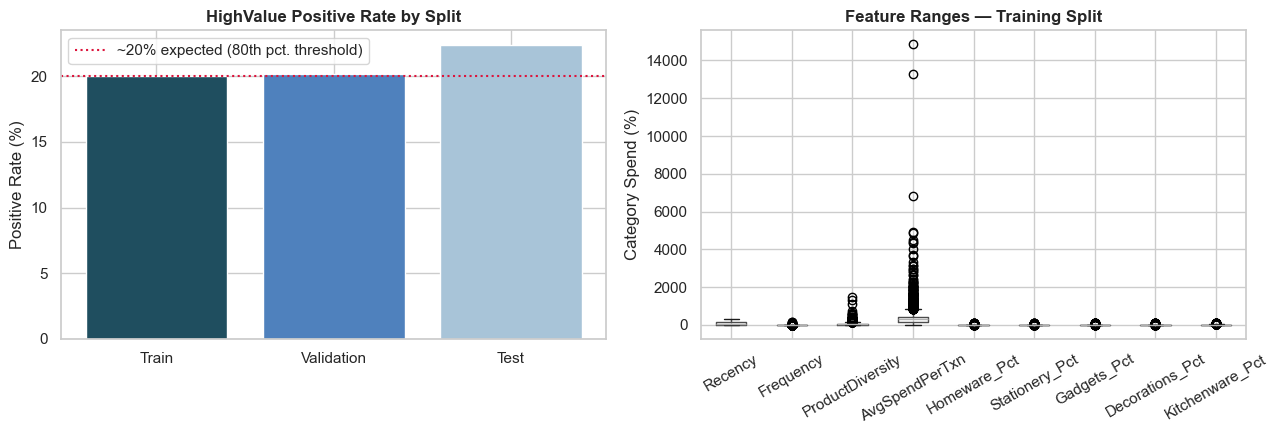

In [4]:
class_balance = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "HighValue=1 Count": [y_train.sum(), y_val.sum(), y_test.sum()],
    "Positive Rate %": [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
})
print(class_balance.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(class_balance["Split"], class_balance["Positive Rate %"], color=["#1F4E5F", "#4F81BD", "#A8C4D8"])
axes[0].axhline(20, color="crimson", linestyle=":", label="~20% expected (80th pct. threshold)")
axes[0].set_title("HighValue Positive Rate by Split", fontweight="bold")
axes[0].set_ylabel("Positive Rate (%)")
axes[0].legend()

train_df[feature_cols].boxplot(ax=axes[1])
axes[1].set_title("Feature Ranges — Training Split", fontweight="bold")
axes[1].set_ylabel("Category Spend (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 2. Model Implementations

### 2.1 Model 1 — Neural Network (`MLPClassifier`)

**Architecture:** `Input(5) → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1, Sigmoid)`. This is a small, deliberately shallow network — with only 5 input features and ~5,000 training rows, a deeper/wider network would be far more likely to overfit than to find genuinely useful non-linear structure.

**Why a neural network at all, on just 5 features?** It's included specifically to test whether *non-linear interactions* between category-spend percentages (e.g. "high Gadgets spend combined with low Kitchenware spend" as a distinct pattern) predict `HighValue` better than a purely linear combination. Whether that hypothesis actually pays off is exactly what the validation-set comparison in Section 3.2 will tell us.

In [5]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
)

mlp_clf.fit(X_train, y_train)
print("\u2705 Model 1: Neural Network successfully trained on training partition.")
print(f"   Converged after {mlp_clf.n_iter_} iterations (max allowed: 500).")

✅ Model 1: Neural Network successfully trained on training partition.
   Converged after 299 iterations (max allowed: 500).


### 🔍 Training Diagnostic — Loss Curve

`MLPClassifier` records its training loss after every iteration. Plotting it tells us whether training actually **converged** (loss flattens out) or was cut off early by `max_iter` while still improving (a sign you may want to raise `max_iter` or reconsider the learning rate).

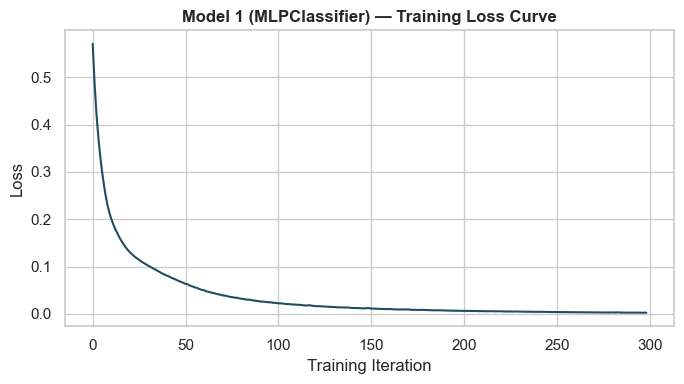

✅ Loss curve has flattened -- training converged normally.


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(mlp_clf.loss_curve_, color="#1F4E5F")
plt.title("Model 1 (MLPClassifier) — Training Loss Curve", fontweight="bold")
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

flattened = mlp_clf.loss_curve_[-1] < mlp_clf.loss_curve_[max(0, len(mlp_clf.loss_curve_) - 20)] * 1.01
print("\u2705 Loss curve has flattened -- training converged normally." if flattened else
      "\u26A0\uFE0F Loss was still decreasing meaningfully at the last iteration -- consider raising max_iter.")

### 2.2 Model 2 — Logistic Regression (baseline)

Chosen as the baseline because it's **linear, fast, and fully interpretable**: every coefficient directly tells you "holding the other 4 category-percentages fixed, how does a 1-standard-deviation increase in *this* category shift the log-odds of being `HighValue`?" That interpretability is valuable on its own — a linear model that performs *almost* as well as a neural network is usually preferable in a business setting, because you can explain *why* it made a given prediction.

In [7]:
baseline_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_clf.fit(X_train, y_train)
print("\u2705 Model 2: Logistic Regression baseline trained on training partition.")

✅ Model 2: Logistic Regression baseline trained on training partition.


### 🔍 Reading the coefficients

A positive coefficient means a 1-standard-deviation increase in that (now-standardized) feature is associated with *higher* odds of being `HighValue`; negative means the opposite. Because every feature was standardized to mean 0 / variance 1 before training (see Section 1), coefficient magnitudes **are** directly comparable across features now — including across the mix of RFM-style and category-% columns, which are on very different raw scales.

         Feature  Coefficient
       Frequency     5.427528
  AvgSpendPerTxn     2.934383
ProductDiversity     0.828794
 Kitchenware_Pct     0.042796
     Gadgets_Pct     0.025128
  Stationery_Pct    -0.097240
 Decorations_Pct    -0.132386
    Homeware_Pct    -0.241079
         Recency    -0.719211


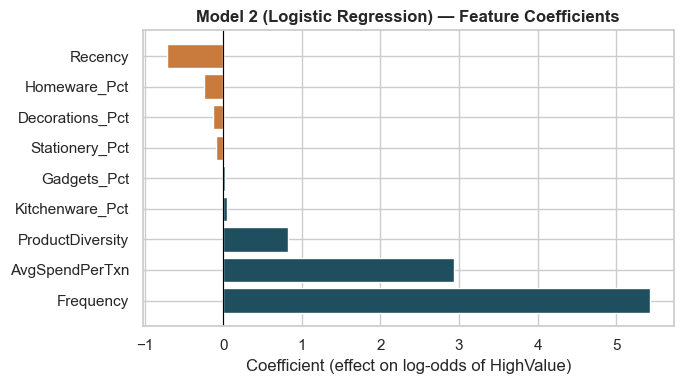

In [8]:
coef_table = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_clf.coef_[0],
}).sort_values("Coefficient", ascending=False)

print(coef_table.to_string(index=False))

plt.figure(figsize=(7, 4))
colors = ["#1F4E5F" if c >= 0 else "#C97B3D" for c in coef_table["Coefficient"]]
plt.barh(coef_table["Feature"], coef_table["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Model 2 (Logistic Regression) — Feature Coefficients", fontweight="bold")
plt.xlabel("Coefficient (effect on log-odds of HighValue)")
plt.tight_layout()
plt.show()

---
## 3. Hyperparameter Tuning and Model Selection

### 3.1 5-Fold Grid Search on the Training Partition Only

We tune Model 1's L2 regularization strength (`alpha`) via `GridSearchCV` with `StratifiedKFold` (5 folds, shuffled). **Stratified** matters here specifically because `HighValue` is imbalanced (~20% positive) — plain `KFold` could by chance produce a fold with very few (or zero) positive examples, making that fold's score meaningless. Stratification guarantees every fold keeps roughly the same ~20% positive rate as the full training set.

We optimize for **F1-score**, not accuracy — with a 20%/80% class split, a model that *always* predicts "LowValue" would already score 80% accuracy while being completely useless. F1 (the harmonic mean of precision and recall) forces the search to actually find models that correctly identify `HighValue` customers, not just the majority class.

In [9]:
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "hidden_layer_sizes": [(32, 16)],
    "alpha": [0.0001, 0.001, 0.01],
}

grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv_splitter,
    scoring="f1",
)

grid.fit(X_train, y_train)
print(f"Best Cross-Validation Parameters found: {grid.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid.best_score_:.4f}")

Best Cross-Validation Parameters found: {'alpha': 0.01, 'hidden_layer_sizes': (32, 16)}
Best Cross-Validation F1-Score: 0.9538


### 🔍 Full Grid Search Results Table & Chart

Rather than only trusting the single "best" result, we inspect **every** alpha value's cross-validated F1-score (mean ± standard deviation across the 5 folds) — this tells us how *sensitive* the model is to this hyperparameter, and whether the "best" choice is a clear winner or basically a coin flip against its neighbors.

 alpha  Mean CV F1  Std CV F1  Rank
0.0001    0.953626   0.006607     2
0.0010    0.948559   0.011542     3
0.0100    0.953755   0.009148     1


C:\Users\shafa\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


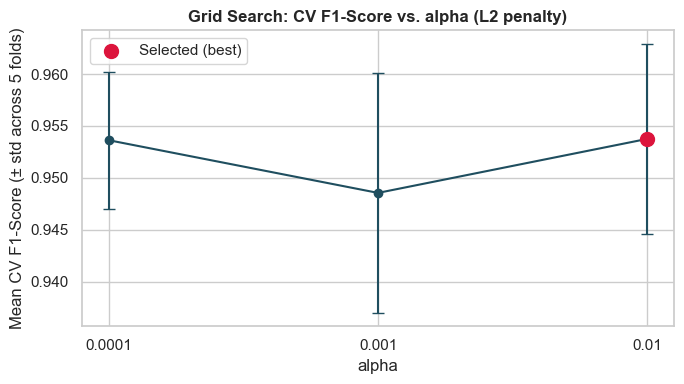

In [10]:
cv_results = pd.DataFrame(grid.cv_results_)[
    ["param_alpha", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("param_alpha")
cv_results.columns = ["alpha", "Mean CV F1", "Std CV F1", "Rank"]
print(cv_results.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.errorbar(
    cv_results["alpha"].astype(str), cv_results["Mean CV F1"],
    yerr=cv_results["Std CV F1"], fmt="o-", color="#1F4E5F", capsize=4,
)
best_alpha = str(grid.best_params_["alpha"])
plt.scatter([best_alpha], [cv_results.loc[cv_results["alpha"].astype(str) == best_alpha, "Mean CV F1"]],
            color="crimson", s=100, zorder=5, label="Selected (best)")
plt.title("Grid Search: CV F1-Score vs. alpha (L2 penalty)", fontweight="bold")
plt.xlabel("alpha")
plt.ylabel("Mean CV F1-Score (\u00b1 std across 5 folds)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Model Selection on the Validation Partition

Now we compare the **tuned** Model 1 against the (untuned, since it has no hyperparameter to tune here) Model 2 baseline — on the validation split, exactly once, using the **full metric suite** rather than just F1, so the selection decision is transparent.

=== Validation Metric Comparison ===
                               Accuracy  Precision  Recall  F1-Score
Model 1: Tuned Neural Network    0.9890     0.9726  0.9726    0.9726
Model 2: Logistic Regression     0.9337     0.8657  0.7945    0.8286


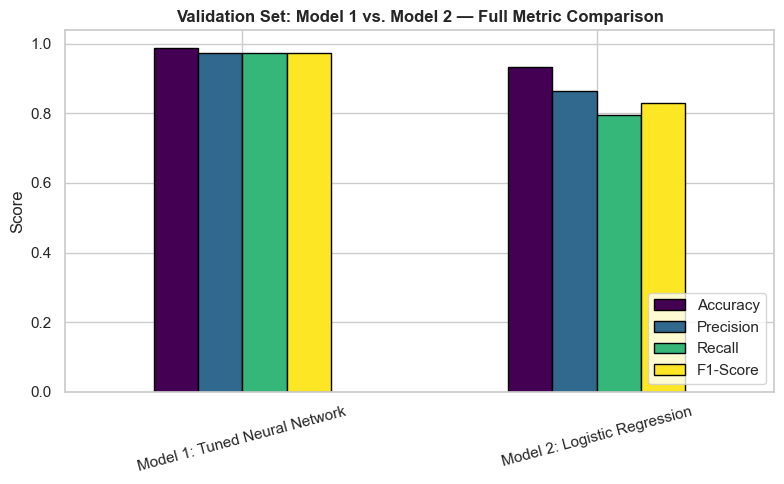


🏆 Selected Champion (by validation F1-Score): Model 1: Tuned Neural Network


In [11]:
# Predict validation metrics
val_pred_nn = grid.best_estimator_.predict(X_val)
val_pred_bl = baseline_clf.predict(X_val)

val_comparison = pd.DataFrame({
    "Model 1: Tuned Neural Network": {
        "Accuracy":  accuracy_score(y_val, val_pred_nn),
        "Precision": precision_score(y_val, val_pred_nn, zero_division=0),
        "Recall":    recall_score(y_val, val_pred_nn, zero_division=0),
        "F1-Score":  f1_score(y_val, val_pred_nn, zero_division=0),
    },
    "Model 2: Logistic Regression": {
        "Accuracy":  accuracy_score(y_val, val_pred_bl),
        "Precision": precision_score(y_val, val_pred_bl, zero_division=0),
        "Recall":    recall_score(y_val, val_pred_bl, zero_division=0),
        "F1-Score":  f1_score(y_val, val_pred_bl, zero_division=0),
    },
}).T

print("=== Validation Metric Comparison ===")
print(val_comparison.round(4).to_string())

val_comparison.plot(kind="bar", figsize=(8, 5), colormap="viridis", edgecolor="black")
plt.title("Validation Set: Model 1 vs. Model 2 — Full Metric Comparison", fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Selection Logic (on F1, as originally optimized)
f1_nn = val_comparison.loc["Model 1: Tuned Neural Network", "F1-Score"]
f1_bl = val_comparison.loc["Model 2: Logistic Regression", "F1-Score"]

if f1_nn >= f1_bl:
    final_model = grid.best_estimator_
    champion_name = "Model 1: Tuned Neural Network"
else:
    final_model = baseline_clf
    champion_name = "Model 2: Logistic Regression"

print(f"\n\U0001F3C6 Selected Champion (by validation F1-Score): {champion_name}")

### 3.3 Threshold Tuning on the Validation Set

The default `0.5` decision threshold is not necessarily the best operating point for an imbalanced problem like this (~20% positive). Since `predict_proba` gives us a continuous score, we can pick a different threshold that trades precision for recall.

**Discipline:** we tune the threshold using only the **validation set's** precision-recall curve — never the test set — so the "test touched exactly once" rule from Section 5.1 of the spec is preserved. We select the threshold that maximizes F1 on validation, then apply that fixed threshold (never re-tuned) to the test set in Section 4.

We report both the default-threshold and tuned-threshold results at test time so the trade-off is transparent, not hidden.


In [12]:
# ==========================================
# Threshold tuning on the VALIDATION set only (test set untouched)
# ==========================================
from sklearn.metrics import precision_recall_curve as _prc

if hasattr(final_model, "predict_proba"):
    val_proba = final_model.predict_proba(X_val)[:, 1]
else:
    val_proba = final_model.decision_function(X_val)

val_precisions, val_recalls, val_thresholds = _prc(y_val, val_proba)

# F1 at each threshold (align thresholds with precision/recall pairs; last point has no threshold)
val_f1s = 2 * (val_precisions[:-1] * val_recalls[:-1]) / (val_precisions[:-1] + val_recalls[:-1] + 1e-12)
best_idx = np.argmax(val_f1s)
tuned_threshold = val_thresholds[best_idx]

print("=== THRESHOLD TUNING (Validation Set) ===")
print(f"Default threshold        : 0.5000")
print(f"F1-optimal threshold     : {tuned_threshold:.4f}")
print(f"Validation Precision @ tuned threshold : {val_precisions[best_idx]:.4f}")
print(f"Validation Recall @ tuned threshold    : {val_recalls[best_idx]:.4f}")
print(f"Validation F1 @ tuned threshold         : {val_f1s[best_idx]:.4f}")

# For comparison: validation metrics at the default 0.5 threshold
val_pred_default = (val_proba >= 0.5).astype(int)
print(f"\nValidation F1 @ default 0.5 threshold  : {f1_score(y_val, val_pred_default, zero_division=0):.4f}")


=== THRESHOLD TUNING (Validation Set) ===
Default threshold        : 0.5000
F1-optimal threshold     : 0.4975
Validation Precision @ tuned threshold : 0.9730
Validation Recall @ tuned threshold    : 0.9863
Validation F1 @ tuned threshold         : 0.9796

Validation F1 @ default 0.5 threshold  : 0.9726


---
## 4. Final Evaluation on the Test Partition

We touch the test set **exactly once**, right here, to report the champion's final, honest performance. No further model changes happen after this cell.

In [13]:
test_proba_final = (final_model.predict_proba(X_test)[:, 1]
                    if hasattr(final_model, "predict_proba")
                    else final_model.decision_function(X_test))

# --- Default threshold (0.5) ---
test_pred_default = (test_proba_final >= 0.5).astype(int)
metrics_default = {
    "accuracy": accuracy_score(y_test, test_pred_default),
    "precision": precision_score(y_test, test_pred_default, zero_division=0),
    "recall": recall_score(y_test, test_pred_default, zero_division=0),
    "f1": f1_score(y_test, test_pred_default, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, test_pred_default).tolist(),
}

# --- Tuned threshold (selected on validation set in Section 3.3, applied here unchanged) ---
test_pred_tuned = (test_proba_final >= tuned_threshold).astype(int)
metrics_tuned = {
    "accuracy": accuracy_score(y_test, test_pred_tuned),
    "precision": precision_score(y_test, test_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, test_pred_tuned, zero_division=0),
    "f1": f1_score(y_test, test_pred_tuned, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, test_pred_tuned).tolist(),
}

# `test_pred` / `metrics` are kept as aliases pointing at the tuned-threshold result, since
# that's the version we report as the model's practical operating point and persist to disk.
test_pred = test_pred_tuned
metrics = metrics_tuned

print("=== FINAL TEST PERFORMANCE SUMMARY (CHAMPION) ===")
print(f"Champion Model     : {champion_name}")
print(f"Tuned threshold    : {tuned_threshold:.4f}  (selected on validation set, Section 3.3)\n")

comparison_df = pd.DataFrame({
    "Default (0.5) Threshold": {k: v for k, v in metrics_default.items() if k != "confusion_matrix"},
    "Tuned Threshold": {k: v for k, v in metrics_tuned.items() if k != "confusion_matrix"},
}).round(4)
print(comparison_df.to_string())

print(f"\nConfusion Matrix (Default 0.5 threshold):\n {np.array(metrics_default['confusion_matrix'])}")
print(f"\nConfusion Matrix (Tuned threshold):\n {np.array(metrics_tuned['confusion_matrix'])}")

print("\n--- Full classification report (Tuned Threshold) ---")
print(classification_report(y_test, test_pred_tuned, target_names=["Low-Value", "High-Value"], zero_division=0))

=== FINAL TEST PERFORMANCE SUMMARY (CHAMPION) ===
Champion Model     : Model 1: Tuned Neural Network
Tuned threshold    : 0.4975  (selected on validation set, Section 3.3)

           Default (0.5) Threshold  Tuned Threshold
accuracy                    0.9862           0.9862
precision                   0.9872           0.9872
recall                      0.9506           0.9506
f1                          0.9686           0.9686

Confusion Matrix (Default 0.5 threshold):
 [[280   1]
 [  4  77]]

Confusion Matrix (Tuned threshold):
 [[280   1]
 [  4  77]]

--- Full classification report (Tuned Threshold) ---
              precision    recall  f1-score   support

   Low-Value       0.99      1.00      0.99       281
  High-Value       0.99      0.95      0.97        81

    accuracy                           0.99       362
   macro avg       0.99      0.97      0.98       362
weighted avg       0.99      0.99      0.99       362



### 🔍 Confusion Matrix, ROC Curve & Precision-Recall Curve

Three complementary views of the same test predictions:
- **Confusion matrix** — the raw counts of correct/incorrect predictions per class. In a business context: the bottom-left cell (actual High-Value, predicted Low-Value) represents *missed opportunities* — customers a retention/marketing team would fail to prioritize.
- **ROC curve** — how well the model separates classes across *all* possible decision thresholds, not just the default 0.5. Useful if you might later want to tune the threshold (e.g. to catch more High-Value customers at the cost of more false positives).
- **Precision-Recall curve** — often more informative than ROC for imbalanced classes like ours (~20% positive): it directly shows the trade-off between "of the customers we flag as High-Value, how many really are" (precision) vs. "of all real High-Value customers, how many did we catch" (recall).

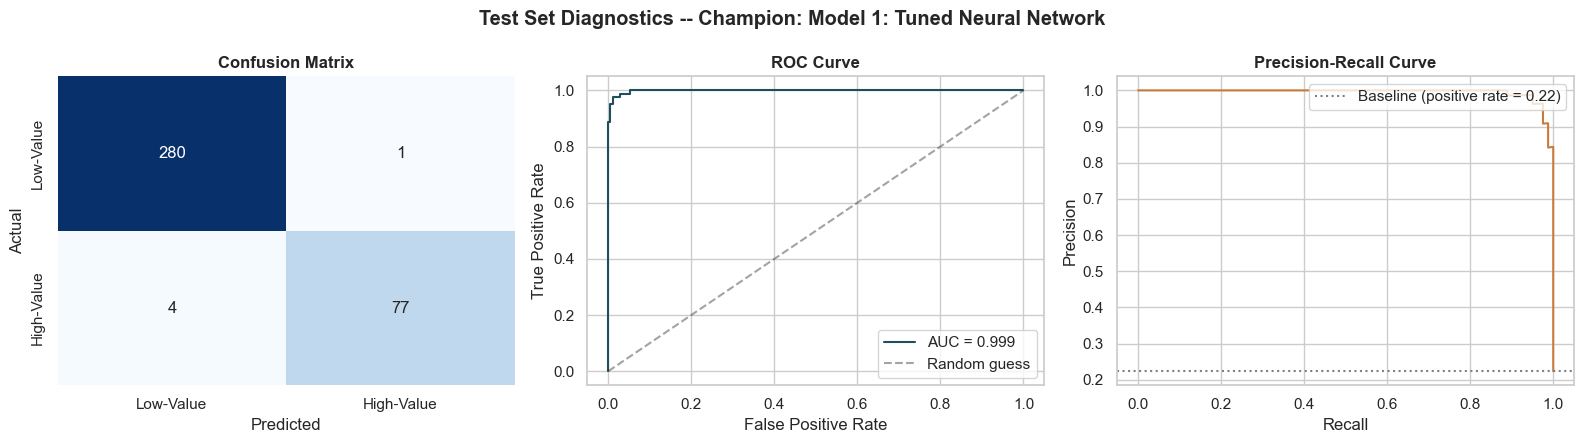

Test ROC-AUC: 0.9985  (0.5 = random guessing, 1.0 = perfect separation)


In [14]:
# Need predicted probabilities for ROC / PR curves
if hasattr(final_model, "predict_proba"):
    test_proba = final_model.predict_proba(X_test)[:, 1]
else:
    test_proba = final_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low-Value", "High-Value"],
            yticklabels=["Low-Value", "High-Value"], ax=axes[0], cbar=False)
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")
axes[0].set_title("Confusion Matrix", fontweight="bold")

axes[1].plot(fpr, tpr, color="#1F4E5F", label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")

axes[2].plot(recall_curve, precision_curve, color="#C97B3D")
axes[2].axhline(y_test.mean(), color="grey", linestyle=":", label=f"Baseline (positive rate = {y_test.mean():.2f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].legend(loc="upper right")

plt.suptitle(f"Test Set Diagnostics -- Champion: {champion_name}", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Test ROC-AUC: {auc:.4f}  (0.5 = random guessing, 1.0 = perfect separation)")

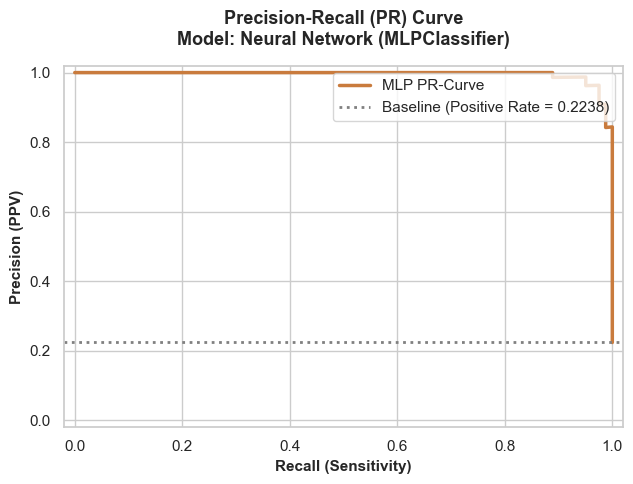

In [15]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
positive_rate = y_test.mean()  # Test set base positive rate (approx 22.38%)

plt.figure(figsize=(6.5, 5))
plt.plot(recall_curve, precision_curve, color="#C97B3D", linewidth=2.5, label="MLP PR-Curve")
plt.axhline(y=positive_rate, color="grey", linestyle=":", linewidth=2,
            label=f"Baseline (Positive Rate = {positive_rate:.4f})")
plt.xlabel("Recall (Sensitivity)", fontweight="bold", fontsize=11)
plt.ylabel("Precision (PPV)", fontweight="bold", fontsize=11)
plt.title("Precision-Recall (PR) Curve\nModel: Neural Network (MLPClassifier)", fontweight="bold", fontsize=13, pad=15)
plt.legend(loc="upper right", frameon=True, fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

---
## 5. Classification Unit Test Verification Suite

These three tests check the **mechanics** of the evaluation pipeline itself — not the model's predictive quality — using small, hand-computable examples. If these ever fail, the bug is in *how we're computing metrics or splitting data*, not in the model.

| Test | Checks |
|---|---|
| **T7.1** | `accuracy_score` computes correctly on a known 4-example input |
| **T7.2** | `confusion_matrix` layout/orientation matches expectation on a known 4-example input |
| **T7.3** | Every `StratifiedKFold` fold index stays strictly inside the training set's index range (no leakage into val/test via a mis-indexed CV split) |

In [16]:
print("=== RUNNING PHASE 2 CLASSIFICATION TEST CASES ===\n")

# T7.1: Accuracy evaluation test check
y_true_t71 = [1, 0, 1, 1]
y_pred_t71 = [1, 0, 0, 1]
acc_t71 = accuracy_score(y_true_t71, y_pred_t71)
print(f"[Test ID T7.1] Input: y_true={y_true_t71}, y_pred={y_pred_t71}")
print(f"               Observed Accuracy : {acc_t71} (Expected: 0.75)")
assert np.isclose(acc_t71, 0.75), "\u274C Test Case T7.1 failed!"
print("\u2705 Test Case T7.1 Passed.\n")

# T7.2: Confusion Matrix evaluation test check
y_true_t72 = [1, 1, 0, 0]
y_pred_t72 = [1, 0, 0, 0]
cm_t72 = confusion_matrix(y_true_t72, y_pred_t72).tolist()
print(f"[Test ID T7.2] Input: y_true={y_true_t72}, y_pred={y_pred_t72}")
print(f"               Observed Matrix   : {cm_t72} (Expected: [[2, 0], [1, 1]])")
assert cm_t72 == [[2, 0], [1, 1]], "\u274C Test Case T7.2 failed!"
print("\u2705 Test Case T7.2 Passed.\n")

# T7.3: Leakage-free CV verification test check
print(f"[Test ID T7.3] Evaluating Cross-Validation split boundaries...")
cv_indices_in_train = True
for train_fold_idx, val_fold_idx in cv_splitter.split(X_train, y_train):
    if np.max(train_fold_idx) >= len(X_train) or np.max(val_fold_idx) >= len(X_train):
        cv_indices_in_train = False

assert cv_indices_in_train, "\u274C Test Case T7.3 Failed! Cross-validation index escaped training split bounds."
print("\u2705 Test Case T7.3 Passed: Cross-validation splits remain strictly locked inside X_train indices bounds.")

print("\n\u2B50 All Phase 2 Classification Unit Test cases successfully passed!")

=== RUNNING PHASE 2 CLASSIFICATION TEST CASES ===

[Test ID T7.1] Input: y_true=[1, 0, 1, 1], y_pred=[1, 0, 0, 1]
               Observed Accuracy : 0.75 (Expected: 0.75)
✅ Test Case T7.1 Passed.

[Test ID T7.2] Input: y_true=[1, 1, 0, 0], y_pred=[1, 0, 0, 0]
               Observed Matrix   : [[2, 0], [1, 1]] (Expected: [[2, 0], [1, 1]])
✅ Test Case T7.2 Passed.

[Test ID T7.3] Evaluating Cross-Validation split boundaries...
✅ Test Case T7.3 Passed: Cross-validation splits remain strictly locked inside X_train indices bounds.

⭐ All Phase 2 Classification Unit Test cases successfully passed!


---
## 6. Save Classification Model Artifacts

We save the champion model to `../data/models/`, alongside a small metadata file recording which model won, its hyperparameters, and its final test metrics — so `05_qlearning_dqn.ipynb` (or anyone auditing this pipeline later) can load the model **and** know exactly what it is without re-reading this whole notebook.

In [17]:
# ==========================================================================
# Persist the champion classifier + metadata (Relative to Notebook Dir)
# ==========================================================================
# '..' steps up from 'notebooks/' into 'project-root/'
model_dir = os.path.join("..", "models") 
os.makedirs(model_dir, exist_ok=True)

model_output_path = os.path.join(model_dir, "champion_classifier.pkl")
joblib.dump(final_model, model_output_path)

# Save the fitted feature scaler too -- any downstream consumer (e.g. app.py) MUST apply this
# same transform to new customer data before calling final_model.predict(), since the model
# was trained on standardized features (Section 1).
scaler_output_path = os.path.join(model_dir, "champion_classifier_scaler.pkl")
joblib.dump(feature_scaler, scaler_output_path)

metadata = {
    "champion_name": champion_name,
    "feature_cols": feature_cols,
    "decision_threshold": float(tuned_threshold),
    "test_metrics_default_threshold": {k: v for k, v in metrics_default.items() if k != "confusion_matrix"},
    "test_metrics_tuned_threshold": {k: v for k, v in metrics_tuned.items() if k != "confusion_matrix"},
    "test_confusion_matrix": metrics["confusion_matrix"],
    "test_roc_auc": float(auc),
    "grid_search_best_params": grid.best_params_,
}
metadata_path = os.path.join(model_dir, "champion_classifier_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"💾 Champion classifier exported to : {os.path.abspath(model_output_path)}")
print(f"💾 Feature scaler exported to       : {os.path.abspath(scaler_output_path)}")
print(f"💾 Metadata exported to             : {os.path.abspath(metadata_path)}")
print(f"   (metadata records decision_threshold={tuned_threshold:.4f} -- apply this instead of 0.5")
print(f"    when using predict_proba() at inference time downstream.)")


💾 Champion classifier exported to : C:\Users\shafa\Documents\Ml Lab\project-root\models\champion_classifier.pkl
💾 Feature scaler exported to       : C:\Users\shafa\Documents\Ml Lab\project-root\models\champion_classifier_scaler.pkl
💾 Metadata exported to             : C:\Users\shafa\Documents\Ml Lab\project-root\models\champion_classifier_metadata.json
   (metadata records decision_threshold=0.4975 -- apply this instead of 0.5
    when using predict_proba() at inference time downstream.)


### 🔍 Verifying the save (round-trip check)

We reload the pickled model and confirm it produces **identical predictions** to the in-memory `final_model` — catching any serialization issue immediately, rather than discovering it inside a downstream notebook.

In [18]:
reloaded_model = joblib.load(model_output_path)
reloaded_pred = reloaded_model.predict(X_test)

assert np.array_equal(reloaded_pred, test_pred), "Reloaded model's predictions differ from the original!"
print("\u2705 champion_classifier.pkl round-trips correctly -- reloaded model produces identical test predictions.")

with open(metadata_path) as f:
    reloaded_meta = json.load(f)
assert reloaded_meta["champion_name"] == champion_name
print("\u2705 champion_classifier_metadata.json round-trips correctly.")

✅ champion_classifier.pkl round-trips correctly -- reloaded model produces identical test predictions.
✅ champion_classifier_metadata.json round-trips correctly.


## ✅ Understanding Checklist

- [ ] Why is the validation set touched only *once* to pick the champion, and the test set only *once* to report final numbers — what specifically goes wrong if you don't follow this discipline?
- [ ] Why does the grid search use `StratifiedKFold` instead of plain `KFold`, given our ~20%/80% class imbalance?
- [ ] Why is the model selected/tuned by **F1-score** rather than accuracy?
- [ ] Looking at the Logistic Regression coefficients chart: which feature most strongly predicts `HighValue`, and in which direction?
- [ ] Why was the feature set expanded beyond the 5 category-% columns, and why is `Monetary` deliberately excluded even though it's a strong predictor?
- [ ] Why is the decision threshold tuned on the *validation* set rather than the test set, and what would go wrong if it were tuned on test instead?
- [ ] In the ROC vs. Precision-Recall curve comparison, why might Precision-Recall be the more informative chart for this specific imbalanced-class problem?
- [ ] Why do we save a `_metadata.json` file (and now a `_scaler.pkl`) alongside the `.pkl` model, rather than just the model file alone?

### Next: `04_regression.ipynb`
This notebook's champion classifier is saved at `../data/models/champion_classifier.pkl`, alongside `champion_classifier_scaler.pkl` (the fitted `StandardScaler`) and metadata recording the tuned `decision_threshold`. The next notebook builds a **regression** model — predicting a continuous next-quarter spend value rather than a binary label — which will ultimately serve as the revenue simulator for the reinforcement-learning notebook.
